# DS 2010: Classification  
## Professor Bahman Moraffah

This notebook builds a complete classification workflow around a real medical dataset.  
The goal is to connect the ideas from class to something students can implement end to end.

We will work with the **Breast Cancer Wisconsin Diagnostic dataset** from `scikit-learn`.  
Each observation contains measurements computed from a digitized image of a breast mass, and the target is:

- `0` = malignant
- `1` = benign

This notebook covers the main ideas from the lecture:

- classification as predicting labels from measurements
- Bayes classifier as a theoretical benchmark
- LDA
- QDA
- logistic regression
- K nearest neighbors
- decision trees
- PCA for visualization and dimension reduction

The notebook is intentionally detailed.  
Read the markdown, run every cell, and compare the models carefully.

## 1. Imports and plotting style
We start by loading the libraries we need.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 2. Load the real-world dataset

This is a binary classification problem.

The features are numeric measurements such as radius, texture, perimeter, smoothness, and related quantities.  
The response is a class label.

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

target_names = data.target_names

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget names:", target_names)
print("\nClass counts:")
print(y.value_counts().sort_index())

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Target names: ['malignant' 'benign']

Class counts:
target
0    212
1    357
Name: count, dtype: int64


## 3. Look at the data

It is always important to inspect the data before fitting any model.

In [4]:
display(X.head())

summary = X.describe().T[["mean", "std", "min", "max"]]
display(summary.head(10))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


## 4. A quick look at class balance

This tells us whether one class is much more common than the other.

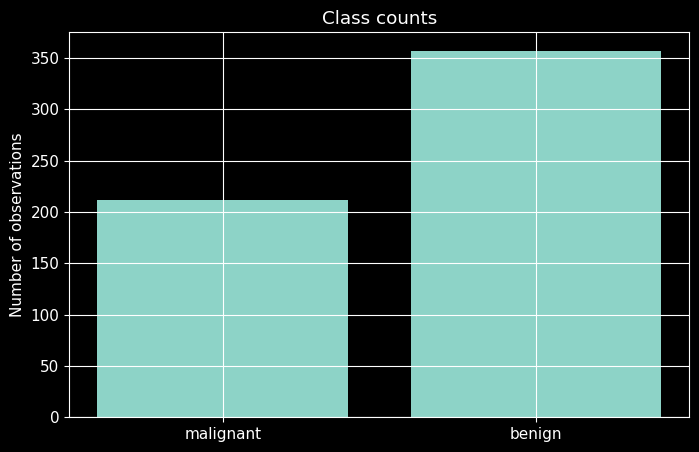

In [5]:
class_counts = y.value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(["malignant", "benign"], class_counts.values)
ax.set_title("Class counts")
ax.set_ylabel("Number of observations")
plt.show()

## 5. Choose two features for first visual intuition

In class, many classification ideas are easiest to understand in two dimensions.  
We will start with two meaningful features:

- `mean radius`
- `mean texture`

Later we will use all features for the main modeling work.

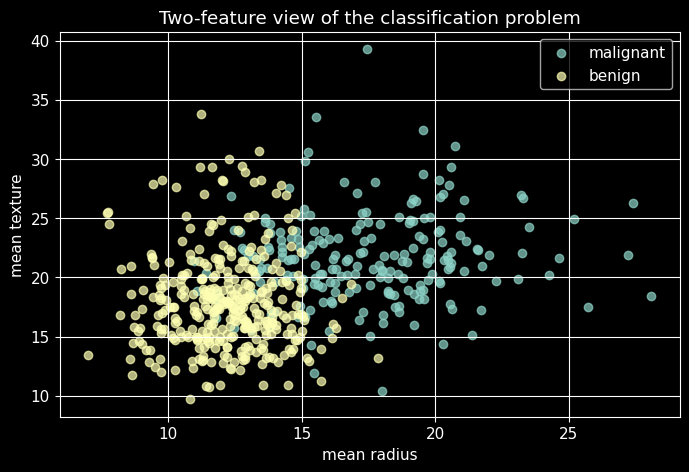

In [6]:
two_features = ["mean radius", "mean texture"]
X2 = X[two_features].copy()

fig, ax = plt.subplots()
for cls, label in zip([0, 1], ["malignant", "benign"]):
    mask = y == cls
    ax.scatter(
        X2.loc[mask, "mean radius"],
        X2.loc[mask, "mean texture"],
        alpha=0.7,
        label=label
    )

ax.set_xlabel("mean radius")
ax.set_ylabel("mean texture")
ax.set_title("Two-feature view of the classification problem")
ax.legend()
plt.show()

## 6. Train-test split

We keep a test set aside so that final evaluation is done on unseen data.

This is important because training accuracy alone can be misleading.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (426, 30)
Test set shape: (143, 30)


## 7. Bayes classifier, what it means, and what we can and cannot do

The Bayes classifier is the ideal rule:

\[
\hat y(x) = \arg\max_k P(Y=k\mid x)
\]

It is a theoretical benchmark because it assumes we know the true class probabilities.

In practice, we do **not** know the true data-generating distribution.  
So we do not implement the Bayes classifier directly here.  
Instead, the practical models below try to approximate it in different ways:

- **LDA and QDA** impose Gaussian class models
- **logistic regression** models class probabilities directly
- **KNN** predicts from nearby observations
- **decision trees** split the feature space recursively

## 8. Helper functions for evaluation and plotting

These functions keep the notebook organized and make comparisons easier.

In [8]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results = {
        "model": model_name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    }

    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, test_proba)
        roc_auc = auc(fpr, tpr)
        results["roc_auc"] = roc_auc
    else:
        results["roc_auc"] = np.nan

    return model, results


def plot_confusion(cm, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["malignant", "benign"])
    ax.set_yticklabels(["malignant", "benign"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.show()


def plot_roc_curves(curves_dict):
    fig, ax = plt.subplots()
    for name, (fpr, tpr, roc_auc) in curves_dict.items():
        ax.plot(fpr, tpr, label=f"{name}  AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curves on the test set")
    ax.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, feature_names):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, alpha=0.25)

    for cls, label in zip([0, 1], ["malignant", "benign"]):
        mask = y == cls
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            label=label,
            alpha=0.8
        )

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend()
    plt.show()

## 9. LDA on the full dataset

From the slides

- LDA assumes each class is Gaussian
- all classes share one covariance matrix
- the resulting decision boundary is linear
- LDA often works well when data is limited and class shapes are similar

In [9]:
lda = LinearDiscriminantAnalysis()
lda, lda_results = evaluate_classifier(lda, X_train, X_test, y_train, y_test, "LDA")
pd.DataFrame([lda_results])

,model,train_accuracy,test_accuracy,roc_auc
0,LDA,0.971831,0.951049,0.99434


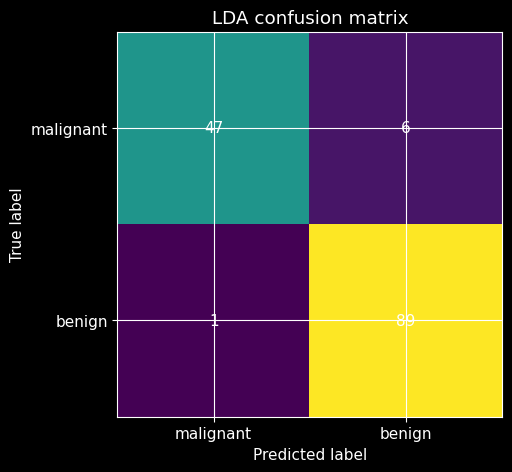

              precision    recall  f1-score   support

   malignant       0.98      0.89      0.93        53
      benign       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



In [10]:
lda_test_pred = lda.predict(X_test)
lda_cm = confusion_matrix(y_test, lda_test_pred)
plot_confusion(lda_cm, "LDA confusion matrix")

print(classification_report(y_test, lda_test_pred, target_names=target_names))

## 10. QDA on the full dataset

From the slides

- QDA also uses Gaussian class models
- each class gets its own covariance matrix
- this usually creates a more flexible curved boundary
- QDA estimates more parameters and often needs more data

In [12]:
qda = QuadraticDiscriminantAnalysis()
qda, qda_results = evaluate_classifier(qda, X_train, X_test, y_train, y_test, "QDA")
pd.DataFrame([qda_results])

LinAlgError: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.

In [ ]:
qda_test_pred = qda.predict(X_test)
qda_cm = confusion_matrix(y_test, qda_test_pred)
plot_confusion(qda_cm, "QDA confusion matrix")

print(classification_report(y_test, qda_test_pred, target_names=target_names))

## 11. Logistic regression on the full dataset

From the slides

- logistic regression models the class probability directly
- it starts from a linear score
- it passes that score through the sigmoid
- the resulting decision boundary is linear in the features

In [13]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

log_reg, logreg_results = evaluate_classifier(
    log_reg, X_train, X_test, y_train, y_test, "Logistic Regression"
)
pd.DataFrame([logreg_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Logistic Regression,0.988263,0.986014,0.997694


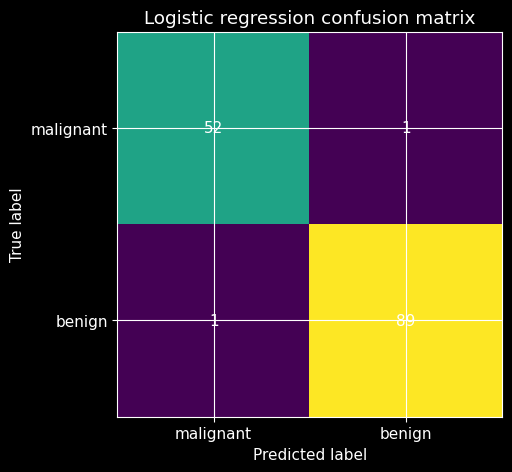

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [14]:
logreg_test_pred = log_reg.predict(X_test)
logreg_cm = confusion_matrix(y_test, logreg_test_pred)
plot_confusion(logreg_cm, "Logistic regression confusion matrix")

print(classification_report(y_test, logreg_test_pred, target_names=target_names))

## 12. K nearest neighbors on the full dataset

From the slides

- KNN predicts using the labels of nearby observations
- KNN depends strongly on distance
- standardization is important
- the choice of $k$ matters

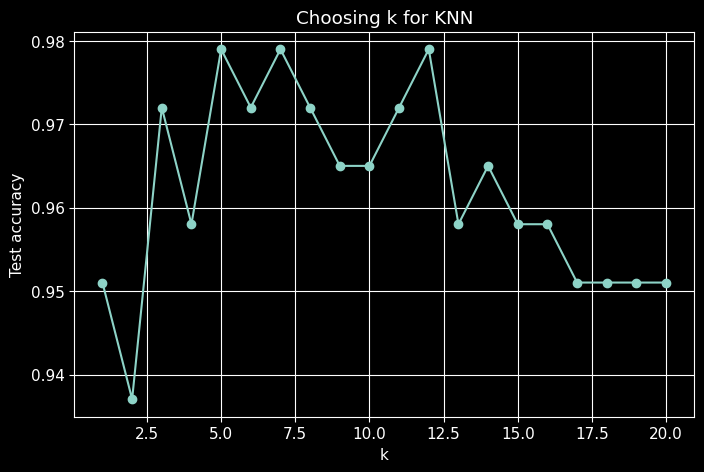

Best k based on test accuracy in this simple sweep: 5


In [15]:
k_values = list(range(1, 21))
knn_scores = []

for k in k_values:
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    knn_model.fit(X_train, y_train)
    test_pred = knn_model.predict(X_test)
    knn_scores.append(accuracy_score(y_test, test_pred))

fig, ax = plt.subplots()
ax.plot(k_values, knn_scores, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Test accuracy")
ax.set_title("Choosing k for KNN")
plt.show()

best_k = k_values[int(np.argmax(knn_scores))]
print("Best k based on test accuracy in this simple sweep:", best_k)

In [16]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

knn, knn_results = evaluate_classifier(knn, X_train, X_test, y_train, y_test, f"KNN (k={best_k})")
pd.DataFrame([knn_results])

,model,train_accuracy,test_accuracy,roc_auc
0,KNN (k=5),0.969484,0.979021,0.984486


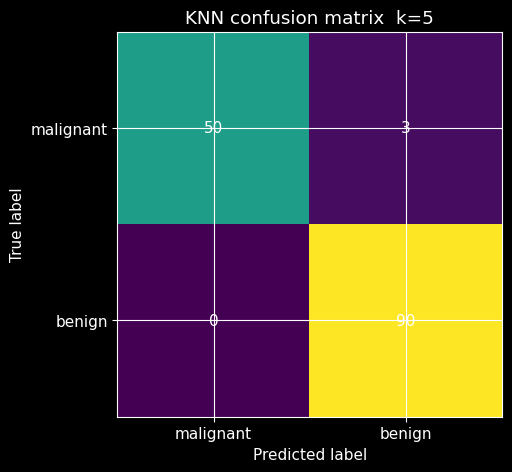

              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        53
      benign       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



In [17]:
knn_test_pred = knn.predict(X_test)
knn_cm = confusion_matrix(y_test, knn_test_pred)
plot_confusion(knn_cm, f"KNN confusion matrix  k={best_k}")

print(classification_report(y_test, knn_test_pred, target_names=target_names))

## 13. Decision tree on the full dataset

Your slides point ahead to decision trees.  
A tree does not fit one global boundary.  
Instead, it creates piecewise decision regions by recursively splitting features.

In [18]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree, tree_results = evaluate_classifier(tree, X_train, X_test, y_train, y_test, "Decision Tree")
pd.DataFrame([tree_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Decision Tree,0.988263,0.944056,0.938365


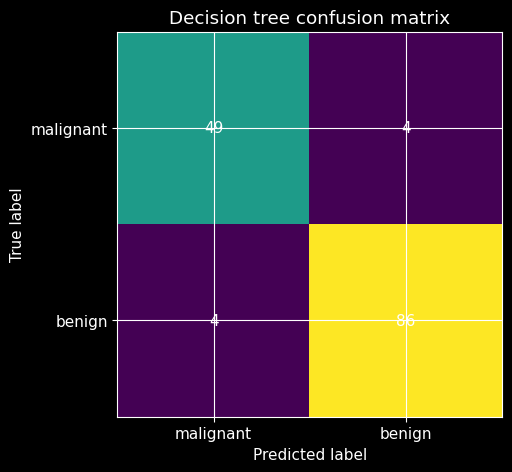

              precision    recall  f1-score   support

   malignant       0.92      0.92      0.92        53
      benign       0.96      0.96      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



In [19]:
tree_test_pred = tree.predict(X_test)
tree_cm = confusion_matrix(y_test, tree_test_pred)
plot_confusion(tree_cm, "Decision tree confusion matrix")

print(classification_report(y_test, tree_test_pred, target_names=target_names))

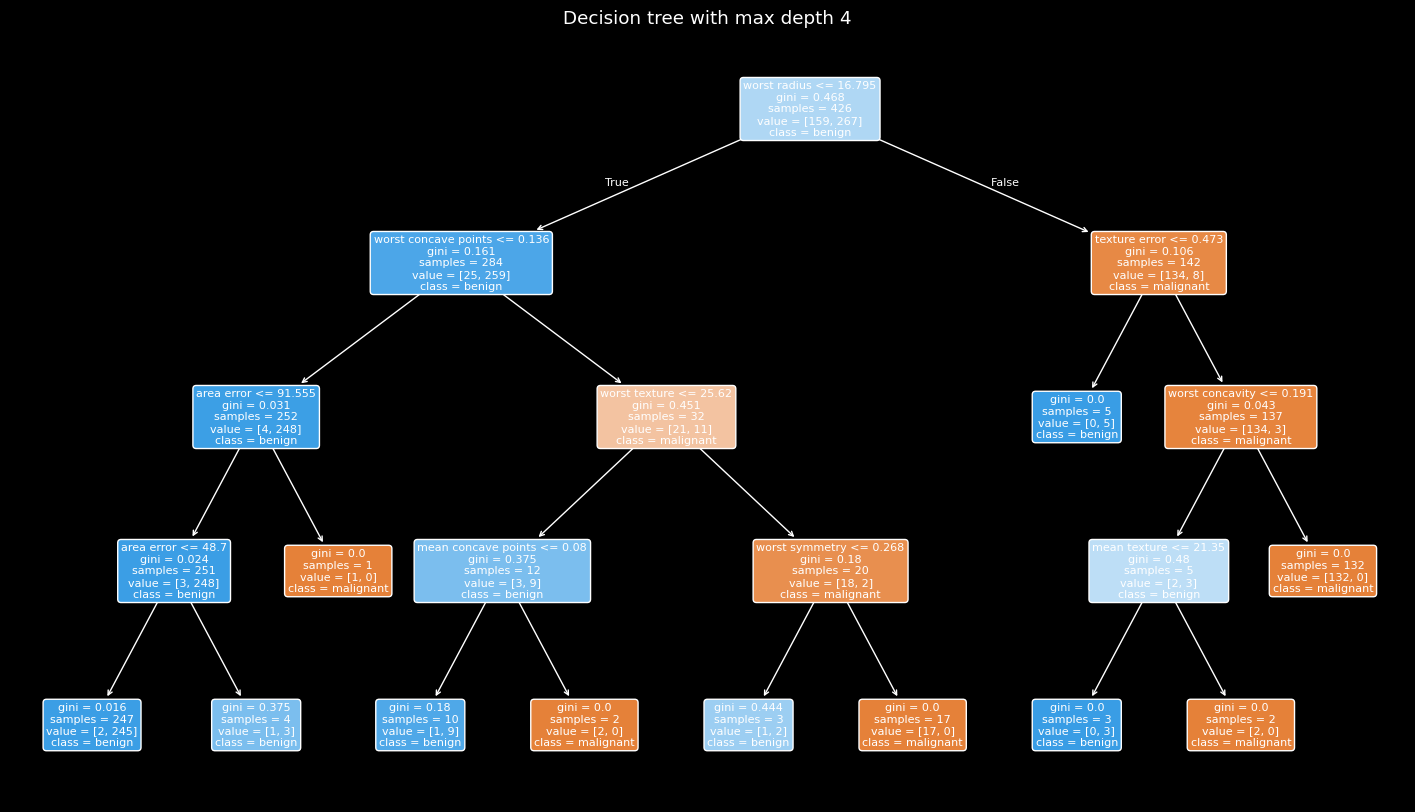

In [20]:
fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title("Decision tree with max depth 4")
plt.show()

## 14. Compare all full-data models in one table

In [22]:
results_df = pd.DataFrame([
    lda_results,
    # qda_results,
    logreg_results,
    knn_results,
    tree_results
])

results_df = results_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
display(results_df)

,model,train_accuracy,test_accuracy,roc_auc
0,Logistic Regression,0.988263,0.986014,0.997694
1,KNN (k=5),0.969484,0.979021,0.984486
2,LDA,0.971831,0.951049,0.994340
3,Decision Tree,0.988263,0.944056,0.938365


## 15. ROC curves for the probabilistic models

ROC curves help us compare how well models separate the classes across thresholds.

We will plot ROC curves for

- LDA
- QDA
- logistic regression
- KNN
- decision tree

In [ ]:
roc_curves = {}

for name, model in [
    ("LDA", lda),
    ("QDA", qda),
    ("Logistic Regression", log_reg),
    (f"KNN (k={best_k})", knn),
    ("Decision Tree", tree)
]:
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        roc_auc = auc(fpr, tpr)
        roc_curves[name] = (fpr, tpr, roc_auc)

plot_roc_curves(roc_curves)

## 16. Why two-dimensional pictures still matter

The full dataset has many features, which is good for modeling but hard for intuition.

To understand decision boundaries visually, we now fit the models using only the two features

- `mean radius`
- `mean texture`

This is not the final modeling setup.  
It is mainly for geometry and interpretation.

## 17. Two-feature LDA, QDA, logistic regression, KNN, and decision tree boundaries

In [ ]:
X2_train_np = X2_train.values
X2_test_np = X2_test.values
y2_train_np = y2_train.values

lda_2 = LinearDiscriminantAnalysis().fit(X2_train_np, y2_train_np)
qda_2 = QuadraticDiscriminantAnalysis().fit(X2_train_np, y2_train_np)

logreg_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
]).fit(X2_train_np, y2_train_np)

knn_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
]).fit(X2_train_np, y2_train_np)

tree_2 = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X2_train_np, y2_train_np)

In [ ]:
plot_decision_boundary(
    lda_2,
    X2_train_np,
    y2_train_np,
    "LDA decision boundary on two features",
    two_features
)

plot_decision_boundary(
    qda_2,
    X2_train_np,
    y2_train_np,
    "QDA decision boundary on two features",
    two_features
)

plot_decision_boundary(
    logreg_2,
    X2_train_np,
    y2_train_np,
    "Logistic regression decision boundary on two features",
    two_features
)

plot_decision_boundary(
    knn_2,
    X2_train_np,
    y2_train_np,
    f"KNN decision boundary on two features  k={best_k}",
    two_features
)

plot_decision_boundary(
    tree_2,
    X2_train_np,
    y2_train_np,
    "Decision tree decision boundary on two features",
    two_features
)

## 18. PCA for structure, visualization, and dimension reduction

Your slides point ahead to PCA.

PCA is not a classifier by itself.  
Instead, it helps us understand the geometry of the data and can reduce the number of features before classification.

We will standardize the data first because PCA is sensitive to scale.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(explained) + 1), cum_explained, marker="o")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance")
plt.show()

for i in range(5):
    print(f"PC{i+1} explained variance ratio: {explained[i]:.4f}")

## 19. Plot the first two principal components

This gives us a low-dimensional view of the structure in the data.

In [ ]:
pca2 = PCA(n_components=2)
X_train_pca2 = pca2.fit_transform(X_train_scaled)
X_test_pca2 = pca2.transform(X_test_scaled)

fig, ax = plt.subplots()
for cls, label in zip([0, 1], ["malignant", "benign"]):
    mask = y_train.values == cls
    ax.scatter(
        X_train_pca2[mask, 0],
        X_train_pca2[mask, 1],
        alpha=0.7,
        label=label
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Training data projected onto the first two principal components")
ax.legend()
plt.show()

## 20. Classification after PCA

Now we try a simple example of dimension reduction followed by classification.

We will keep enough principal components to explain at least 95 percent of the variance, then fit:

- logistic regression
- KNN

This lets students see how PCA can help with structure and dimension.

In [ ]:
n_components_95 = np.argmax(cum_explained >= 0.95) + 1
print("Number of components for at least 95% explained variance:", n_components_95)

In [ ]:
pca_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_95)),
    ("model", LogisticRegression(max_iter=5000))
])

pca_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_95)),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

pca_logreg, pca_logreg_results = evaluate_classifier(
    pca_logreg, X_train, X_test, y_train, y_test, "PCA + Logistic Regression"
)

pca_knn, pca_knn_results = evaluate_classifier(
    pca_knn, X_train, X_test, y_train, y_test, f"PCA + KNN (k={best_k})"
)

display(pd.DataFrame([pca_logreg_results, pca_knn_results]))

## 21. Final comparison table

In [ ]:
final_results = pd.DataFrame([
    lda_results,
    qda_results,
    logreg_results,
    knn_results,
    tree_results,
    pca_logreg_results,
    pca_knn_results
])

final_results = final_results.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
display(final_results)

## 22. Interpretation questions for students

After running the notebook, answer these questions in words.

1. Which method had the highest test accuracy  
2. Did QDA outperform LDA here, or did the simpler shared-covariance model do just as well  
3. How sensitive was KNN to the choice of $k$  
4. Which method produced the most irregular decision boundary in two dimensions  
5. Did PCA help or hurt the models in this dataset  
6. Which methods provide probabilities directly  
7. Which method looks easiest to explain to a nontechnical audience  
8. Which method would you trust most if interpretability mattered

## 23. What each method is really doing

This notebook is meant to connect class ideas to implementation.

- **Bayes classifier** is the theoretical best rule if the truth were known
- **LDA** assumes Gaussian classes with a shared covariance matrix
- **QDA** assumes Gaussian classes with different covariance matrices
- **logistic regression** models class probability directly
- **KNN** predicts from local neighborhoods
- **decision trees** split feature space recursively
- **PCA** is not a classifier, but it helps reveal structure and reduce dimension

Different assumptions create different boundaries.
That is the main story of classification.